# 📊 Phân Tích Khám Phá Dữ Liệu (EDA) — Bộ Dữ Liệu Rủi Ro Tín Dụng

---

> 🎯 **Mục tiêu:** Khám phá mối quan hệ giữa các biến đặc trưng và biến mục tiêu `loan_status` nhằm phát hiện những tín hiệu ban đầu của **rủi ro vỡ nợ** (default risk).

> 📝 **Phương pháp:** Sử dụng phân tích đơn biến và đa biến kết hợp trực quan hóa dữ liệu để đánh giá tác động của từng yếu tố lên khả năng vỡ nợ.

---


In [132]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
pd.options.display.float_format = "{:.3f}".format


In [133]:
data = pd.read_csv("../data/raw/credit_risk_dataset.csv")
data.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.000,PERSONAL,D,35000,16.020,1,0.590,Y,3
1,21,9600,OWN,5.000,EDUCATION,B,1000,11.140,0,0.100,N,2
2,25,9600,MORTGAGE,1.000,MEDICAL,C,5500,12.870,1,0.570,N,3
3,23,65500,RENT,4.000,MEDICAL,C,35000,15.230,1,0.530,N,2
4,24,54400,RENT,8.000,MEDICAL,C,35000,14.270,1,0.550,Y,4


In [134]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [135]:
pd.crosstab(
    data["person_home_ownership"],
    data["loan_status"],
    normalize="index"
).round(3)

loan_status,0,1
person_home_ownership,,
MORTGAGE,0.874,0.126
OTHER,0.692,0.308
OWN,0.925,0.075
RENT,0.684,0.316


### 🏠 Nhận xét — Tình trạng sở hữu nhà (`person_home_ownership`)

| Nhóm | Tỷ lệ nợ xấu | Đánh giá |
|------|:---:|:---:|
| 🏡 **OWN** — Sở hữu nhà | ~7.5% | ✅ An toàn nhất |
| 🏗️ **MORTGAGE** — Đang trả góp nhà | ~12.6% | ⚠️ Rủi ro trung bình |
| 🏢 **RENT** — Thuê nhà | ~30.8% | 🔴 Rủi ro cao |
| ❓ **OTHER** — Khác | ~31.6% | 🔴 Rủi ro cao nhất |

> 💡 **Insight:** Khách hàng sở hữu nhà riêng có khả năng tài chính ổn định hơn, dẫn đến tỷ lệ vỡ nợ thấp hơn đáng kể so với các nhóm còn lại.


In [136]:
data["loan_status"].value_counts(normalize=True).rename("proportion").mul(100).round(2)

loan_status
0   78.180
1   21.820
Name: proportion, dtype: float64

In [137]:
data.groupby("loan_status")["person_income"].mean().round(0)

loan_status
0   70804.000
1   49126.000
Name: person_income, dtype: float64

### 💰 Nhận xét — Thu nhập cá nhân (`person_income`)

| Nhóm | Thu nhập trung bình |
|------|:---:|
| ✅ Trả được nợ (Non-default) | **~$70,804** |
| ❌ Vỡ nợ (Default) | **~$49,126** |

> 💡 **Insight:** Thu nhập trung bình của nhóm **trả được nợ** cao hơn đáng kể (~44%) so với nhóm vỡ nợ. Điều này gợi ý rằng **thu nhập thấp là một yếu tố rủi ro quan trọng** trong đánh giá tín dụng.


In [138]:
data.groupby("loan_status")["loan_percent_income"].mean().mul(100).round(2)

loan_status
0   14.880
1   24.690
Name: loan_percent_income, dtype: float64

### 📉 Nhận xét — Tỷ lệ khoản vay trên thu nhập (`loan_percent_income`)

| Nhóm | Tỷ lệ vay/thu nhập |
|------|:---:|
| ✅ Trả được nợ | **14.88%** |
| ❌ Vỡ nợ | **24.69%** |

> ⚠️ **Cảnh báo:** Tỷ lệ chênh lệch rất rõ ràng — gánh nặng khoản vay càng lớn so với thu nhập, khả năng vỡ nợ càng cao. Đây là một trong những **biến dự báo mạnh nhất** cho rủi ro tín dụng.


In [139]:
data.groupby("loan_status")["loan_percent_income"].describe().round(3)

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
0,25473.000,0.149,0.087,0.000,0.080,0.130,0.200,0.830
1,7108.000,0.247,0.132,0.010,0.140,0.240,0.340,0.780


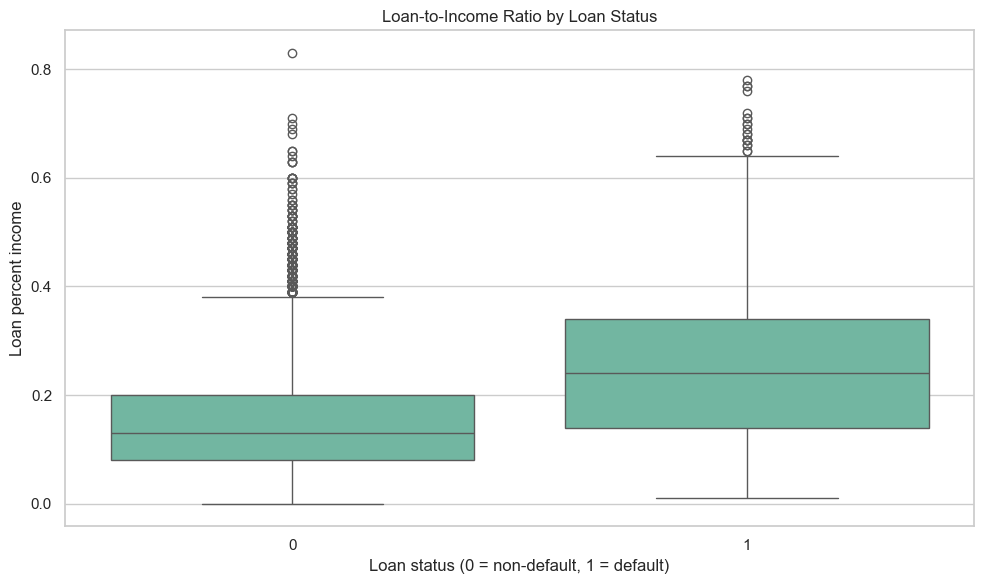

In [140]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x="loan_status", y="loan_percent_income")
plt.title("Loan-to-Income Ratio by Loan Status")
plt.xlabel("Loan status (0 = non-default, 1 = default)")
plt.ylabel("Loan percent income")
plt.tight_layout()

### 🔍 Nhận xét — Kiểm tra giá trị ngoại lai (Outliers)

> ✅ Mặc dù xuất hiện một số trường hợp có tỷ lệ vay trên thu nhập **khá cao**, các điểm này vẫn có vẻ là hồ sơ vay **hợp lệ** hơn là lỗi dữ liệu (data entry errors). 

> 📌 **Quyết định:** Giữ lại toàn bộ dữ liệu để tiếp tục phân tích — không loại bỏ outliers ở bước này.


In [141]:
pd.crosstab(
    data["loan_grade"],
    data["loan_status"],
    normalize="index"
).round(3)

loan_status,0,1
loan_grade,,
A,0.900,0.100
B,0.837,0.163
C,0.793,0.207
D,0.410,0.590
E,0.356,0.644
F,0.295,0.705
G,0.016,0.984


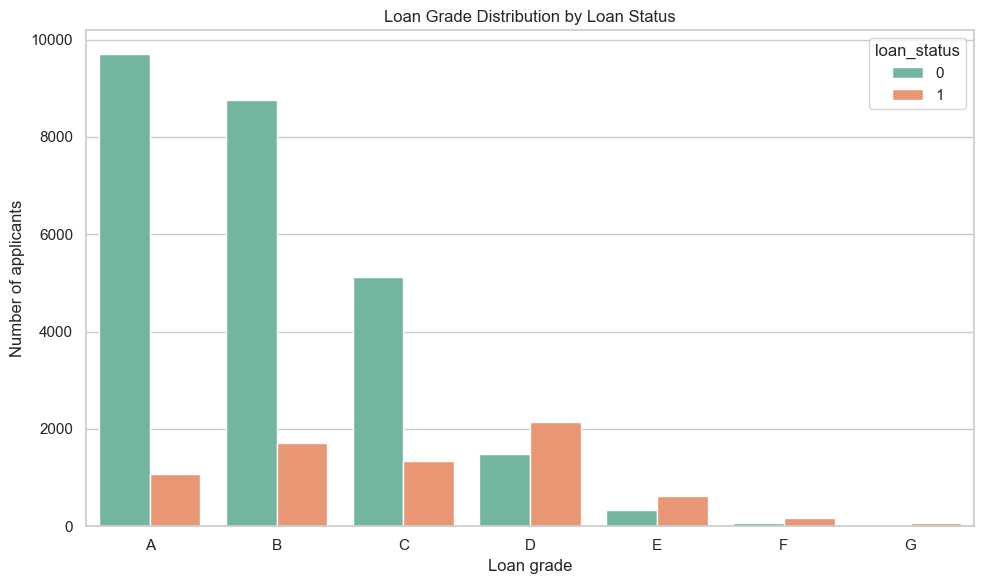

In [142]:
loan_grade = sorted(data["loan_grade"].unique())
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x="loan_grade", hue="loan_status", order=loan_grade)
plt.title("Loan Grade Distribution by Loan Status")
plt.xlabel("Loan grade")
plt.ylabel("Number of applicants")
plt.tight_layout()

### 🏷️ Nhận xét — Hạng khoản vay (`loan_grade`)

> 📊 Nhóm có `loan_grade` **thấp hơn** (D, E, F, G) thể hiện tỷ lệ vỡ nợ **cao hơn rõ rệt** so với nhóm cao (A, B).

> 📈 Xu hướng này khá **nhất quán** từ grade `A` → `G`, cho thấy đây là một biến phân loại có **tính dự báo rất mạnh**.

> 🔑 **Kết luận:** `loan_grade` nên là một trong những biến **ưu tiên hàng đầu** trong bước xây dựng mô hình (modeling).


In [143]:
pd.crosstab(
    data["cb_person_default_on_file"],
    data["loan_status"],
    normalize="index"
).round(3)

loan_status,0,1
cb_person_default_on_file,,
N,0.816,0.184
Y,0.622,0.378


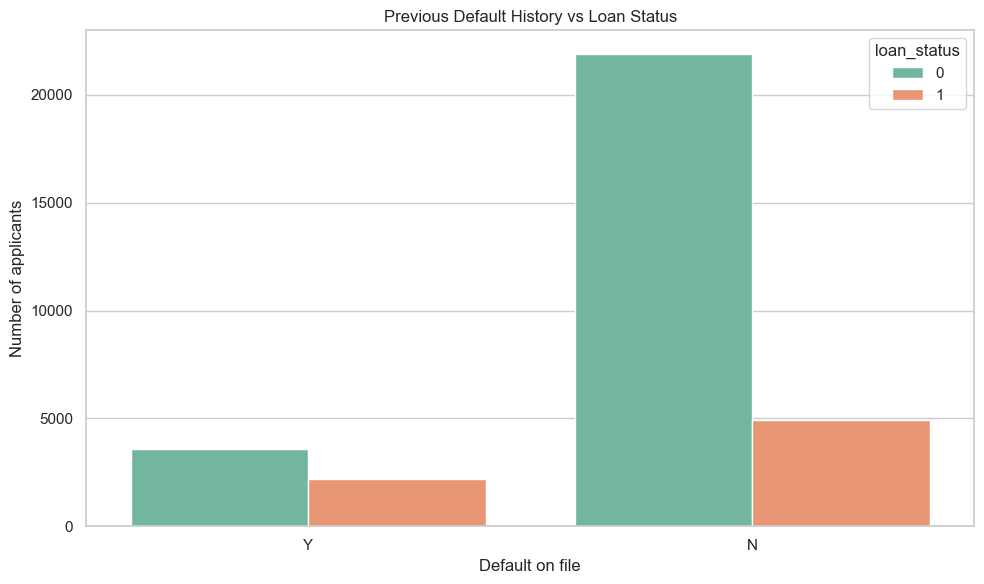

In [144]:
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x="cb_person_default_on_file", hue="loan_status")
plt.title("Previous Default History vs Loan Status")
plt.xlabel("Default on file")
plt.ylabel("Number of applicants")
plt.tight_layout()

### 📜 Nhận xét — Lịch sử vỡ nợ trước đó (`cb_person_default_on_file`)

| Nhóm | Tỷ lệ vỡ nợ hiện tại |
|------|:---:|
| 🟢 Không có tiền sử vỡ nợ (`N`) | **18.4%** |
| 🔴 Có tiền sử vỡ nợ (`Y`) | **37.8%** |

> ⚠️ **Cảnh báo:** Khách hàng từng có tiền sử vỡ nợ có tỷ lệ default hiện tại **gấp đôi** so với nhóm không có tiền sử. Đây là tín hiệu rủi ro **rất đáng tin cậy**.


In [145]:
pd.crosstab(
    data["loan_intent"],
    data["loan_status"],
    normalize="index"
).round(3)

loan_status,0,1
loan_intent,,
DEBTCONSOLIDATION,0.714,0.286
EDUCATION,0.828,0.172
HOMEIMPROVEMENT,0.739,0.261
MEDICAL,0.733,0.267
PERSONAL,0.801,0.199
VENTURE,0.852,0.148


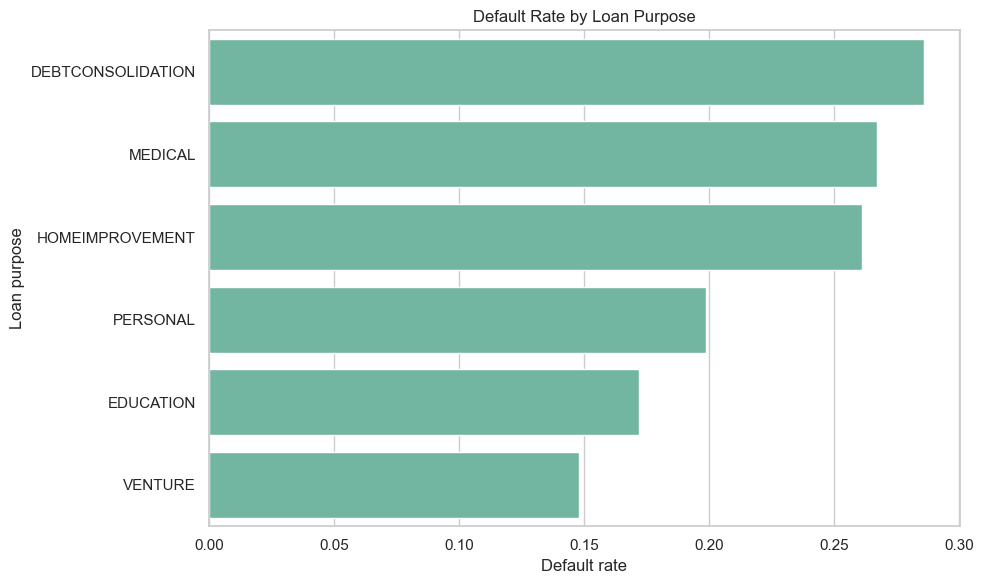

In [146]:
intent_default_rate = pd.crosstab(
    data["loan_intent"],
    data["loan_status"],
    normalize="index"
)[1].sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=intent_default_rate.values, y=intent_default_rate.index)
plt.title("Default Rate by Loan Purpose")
plt.xlabel("Default rate")
plt.ylabel("Loan purpose")
plt.tight_layout()

### 🎯 Nhận xét — Mục đích vay (`loan_intent`)

| Mục đích vay | Tỷ lệ vỡ nợ | Đánh giá |
|------|:---:|:---:|
| 💳 DEBTCONSOLIDATION — Gộp nợ | Cao | 🔴 Rủi ro cao |
| 🏥 MEDICAL — Y tế | Cao | 🔴 Rủi ro cao |
| 🏠 HOMEIMPROVEMENT — Cải tạo nhà | Cao | 🟠 Rủi ro trên trung bình |
| 🎓 EDUCATION — Giáo dục | Thấp | 🟢 Rủi ro thấp |
| 🚀 VENTURE — Kinh doanh | Thấp | 🟢 Rủi ro thấp nhất |

> 💡 **Insight:** Mục đích vay phản ánh tình trạng tài chính hiện tại — những người vay để **gộp nợ** thường đang trong tình trạng tài chính khó khăn, dẫn đến rủi ro vỡ nợ cao hơn.


In [147]:
pd.crosstab(
    data["cb_person_cred_hist_length"],
    data["loan_status"],
    normalize="index"
).round(3)

loan_status,0,1
cb_person_cred_hist_length,,
2,0.764,0.236
3,0.777,0.223
4,0.777,0.223
5,0.794,0.206
6,0.792,0.208
7,0.801,0.199
8,0.787,0.213
9,0.792,0.208
10,0.797,0.203


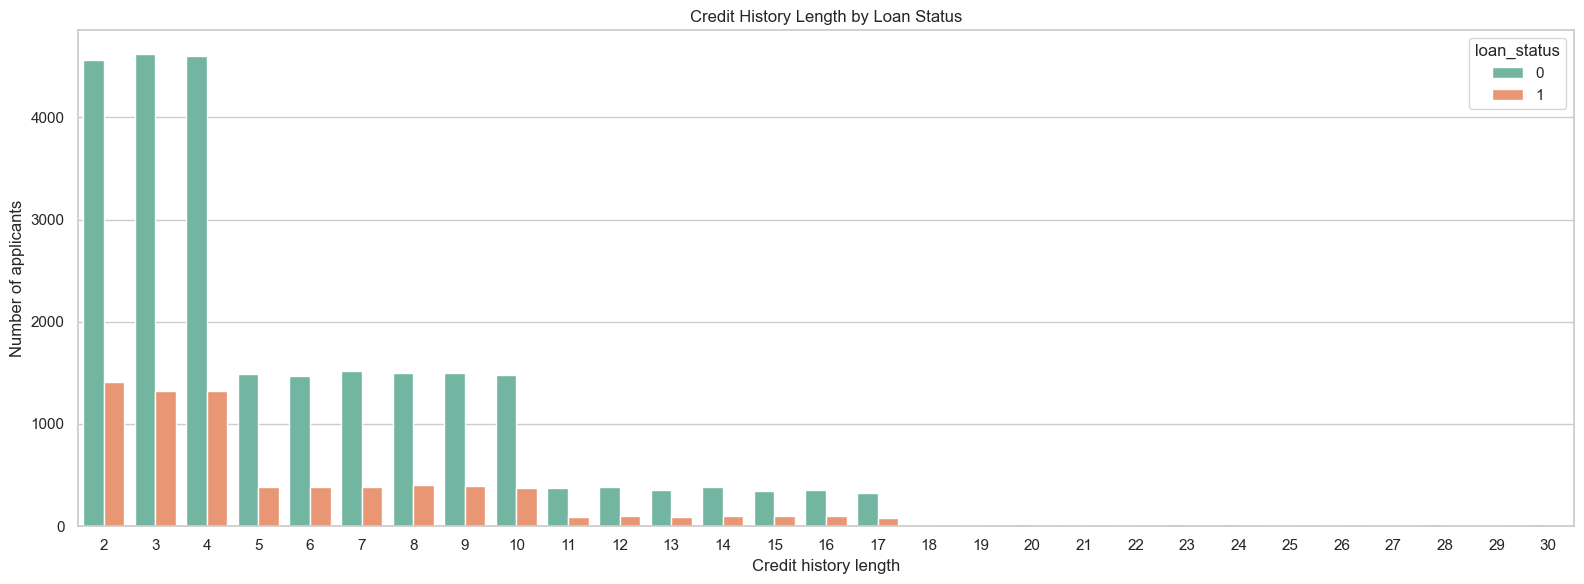

In [148]:
plt.figure(figsize=(16, 6))
sns.countplot(data=data, x="cb_person_cred_hist_length", hue="loan_status")
plt.title("Credit History Length by Loan Status")
plt.xlabel("Credit history length")
plt.ylabel("Number of applicants")
plt.tight_layout()

### 📅 Nhận xét — Thời gian lịch sử tín dụng (`cb_person_cred_hist_length`)

> ❓ **Kết quả:** Chưa tìm thấy bằng chứng mạnh rằng `cb_person_cred_hist_length` có ảnh hưởng **rõ ràng và đơn biến** đến rủi ro vỡ nợ.

> 📌 **Lưu ý:** Biến này có thể vẫn hữu ích khi **kết hợp với các biến khác** trong mô hình đa biến, nhưng đứng riêng thì tín hiệu chưa thật nổi bật.


---

## 📋 Tổng Kết Các Phát Hiện Chính

| # | Biến | Phát hiện | Mức độ ảnh hưởng |
|:---:|------|------|:---:|
| 1 | 💰 `person_income` | Thu nhập thấp → rủi ro vỡ nợ cao hơn | ⭐⭐⭐ |
| 2 | 📉 `loan_percent_income` | Tỷ lệ vay/thu nhập càng cao → rủi ro càng lớn | ⭐⭐⭐⭐ |
| 3 | 🏷️ `loan_grade` | Grade thấp (D-G) → tín hiệu rủi ro rất mạnh | ⭐⭐⭐⭐⭐ |
| 4 | 📜 `cb_person_default_on_file` | Có tiền sử vỡ nợ → xác suất default cao gấp đôi | ⭐⭐⭐⭐ |
| 5 | 🎯 `loan_intent` | Vay gộp nợ, y tế, cải tạo nhà → rủi ro cao hơn | ⭐⭐⭐ |
| 6 | 📅 `cb_person_cred_hist_length` | Tác động đơn biến chưa rõ ràng | ⭐ |
| 7 | 🏠 `person_home_ownership` | Sở hữu nhà → an toàn hơn thuê nhà | ⭐⭐⭐ |

> 🔑 **Kết luận tổng quát:** Các biến `loan_grade`, `loan_percent_income` và `cb_person_default_on_file` là **ba yếu tố dự báo mạnh nhất** cho rủi ro vỡ nợ, nên được ưu tiên trong quá trình xây dựng mô hình.

---


In [149]:
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder(categories=[
    ['G', 'F', 'E', 'D', 'C', 'B', 'A'],      
    ['VENTURE', 'EDUCATION', 'PERSONAL', 'HOMEIMPROVEMENT', 'MEDICAL', 'DEBTCONSOLIDATION'],
    ['N', 'Y'],
    ['OWN',	'MORTGAGE', 'OTHER', 'RENT']
])
cols_to_encode = ['loan_grade', 'loan_intent', 'cb_person_default_on_file', 'person_home_ownership']
data[cols_to_encode] = encoder.fit_transform(data[cols_to_encode])

In [150]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  float64
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  float64
 5   loan_grade                  32581 non-null  float64
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  float64
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(7), int64(5)
memory usage: 3.0 MB


In [151]:
data["person_emp_length_missing"] = (
    data["person_emp_length"].isna().astype(int)
)

data["person_emp_length"] = (
    data["person_emp_length"]
    .fillna(data["person_emp_length"].median())
)
data["int_rate_missing"] = (
    data["loan_int_rate"].isna().astype(int)
)
data["loan_int_rate"] = (
    data.groupby("loan_grade")["loan_int_rate"]
        .transform(lambda x: x.fillna(x.median()))
)

In [152]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  float64
 3   person_emp_length           32581 non-null  float64
 4   loan_intent                 32581 non-null  float64
 5   loan_grade                  32581 non-null  float64
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               32581 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  float64
 11  cb_person_cred_hist_length  32581 non-null  int64  
 12  person_emp_length_missing   32581 non-null  int64  
 13  int_rate_missing            325

In [153]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
rs = RobustScaler()
columns = data.drop(columns=["loan_status"]).columns
X = data[columns]
y = data['loan_status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train = rs.fit_transform(X_train)
X_test = rs.transform(X_test)

In [154]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [155]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score    
)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.79      0.85      5095
           1       0.51      0.78      0.62      1422

    accuracy                           0.79      6517
   macro avg       0.72      0.79      0.74      6517
weighted avg       0.84      0.79      0.80      6517



In [156]:
from catboost import CatBoostClassifier
cb = CatBoostClassifier(
    iterations=300,
    loss_function='Logloss',
    learning_rate=0.01,
    custom_metric=['AUC'],
    verbose=0,
    random_state=42
)
cb.fit(X_train, y_train)
cb_pred = cb.predict(X_test)
print(classification_report(y_test, cb_pred))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96      5095
           1       0.99      0.69      0.81      1422

    accuracy                           0.93      6517
   macro avg       0.95      0.85      0.89      6517
weighted avg       0.94      0.93      0.93      6517



In [157]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96      5095
           1       0.98      0.71      0.82      1422

    accuracy                           0.93      6517
   macro avg       0.95      0.85      0.89      6517
weighted avg       0.94      0.93      0.93      6517



---

# 🤖 Phân Tích Tầm Quan Trọng Đặc Trưng (Feature Importance)

> 🔬 Sau khi hoàn thành việc huấn luyện mô hình, bước tiếp theo là kiểm tra xem **các insight từ EDA** có được **xác nhận bởi mô hình machine learning** hay không.

> 📊 So sánh feature importance giữa **Random Forest** và **CatBoost** để đánh giá tính nhất quán của các phát hiện.

---


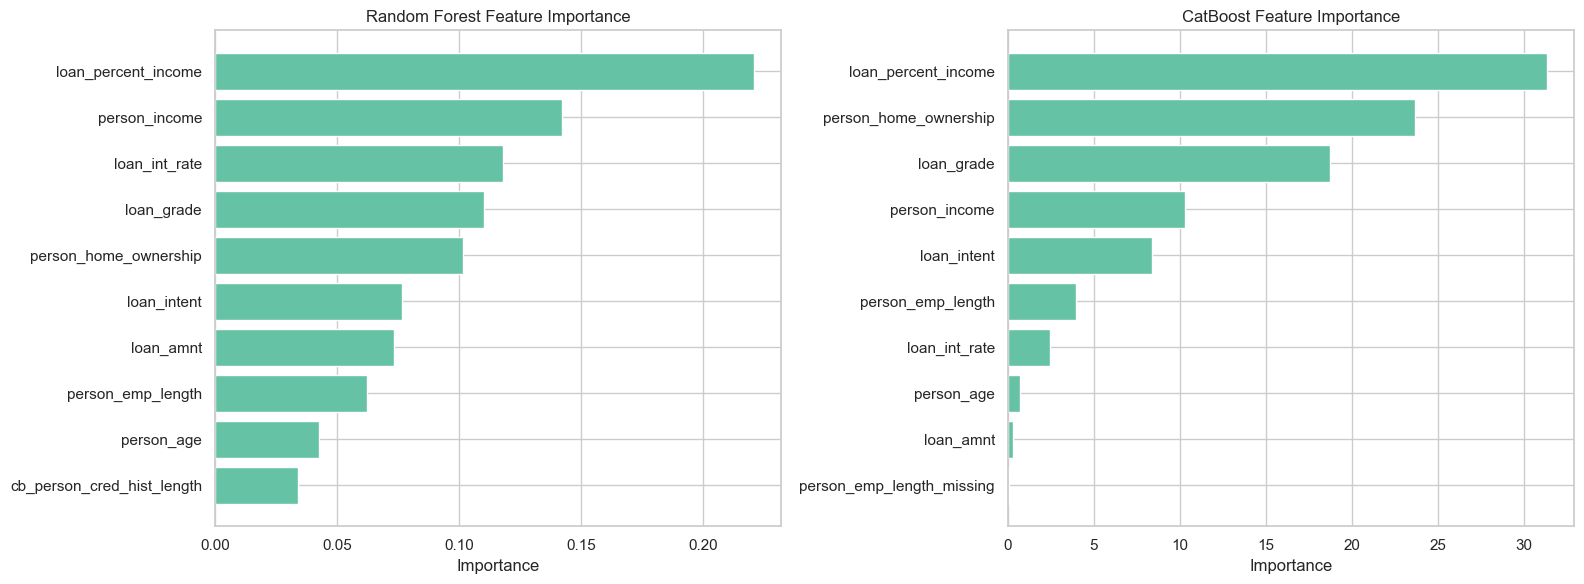

In [158]:
rf_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)
cb_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": cb.feature_importances_
}).sort_values("importance", ascending=False)
fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 6)
)
axes[0].barh(
    rf_importance.head(10)["feature"][::-1],
    rf_importance.head(10)["importance"][::-1]
)
axes[0].set_title("Random Forest Feature Importance")
axes[0].set_xlabel("Importance")
axes[1].barh(
    cb_importance.head(10)["feature"][::-1],
    cb_importance.head(10)["importance"][::-1]
)
axes[1].set_title("CatBoost Feature Importance")
axes[1].set_xlabel("Importance")
plt.tight_layout()
plt.show()

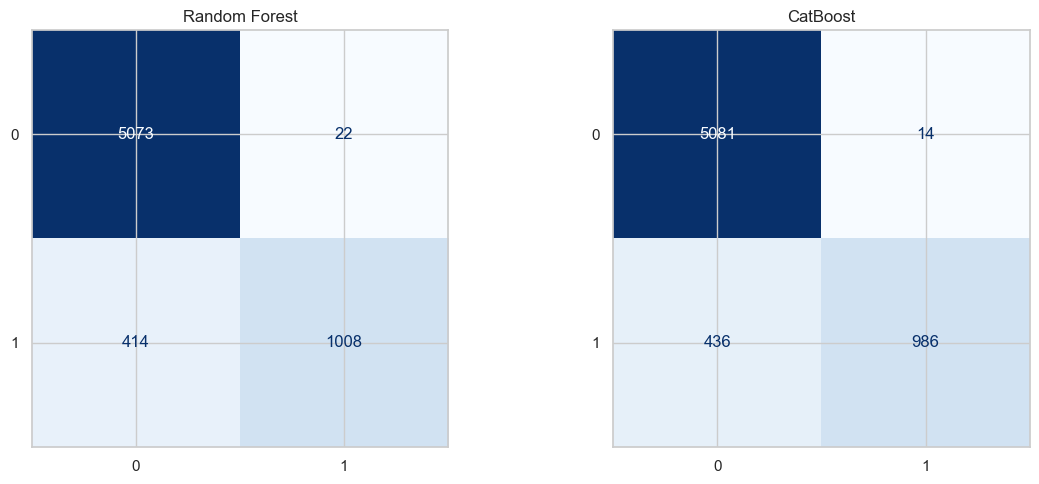

In [159]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
rf_cm = confusion_matrix(y_test, rf_pred)
cb_cm = confusion_matrix(y_test, cb_pred)

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5)
)
ConfusionMatrixDisplay(
    confusion_matrix=rf_cm
).plot(
    ax=axes[0],
    cmap="Blues",
    colorbar=False
)

axes[0].set_title("Random Forest")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

ConfusionMatrixDisplay(
    confusion_matrix=cb_cm
).plot(
    ax=axes[1],
    cmap="Blues",
    colorbar=False
)
axes[1].set_title("CatBoost")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

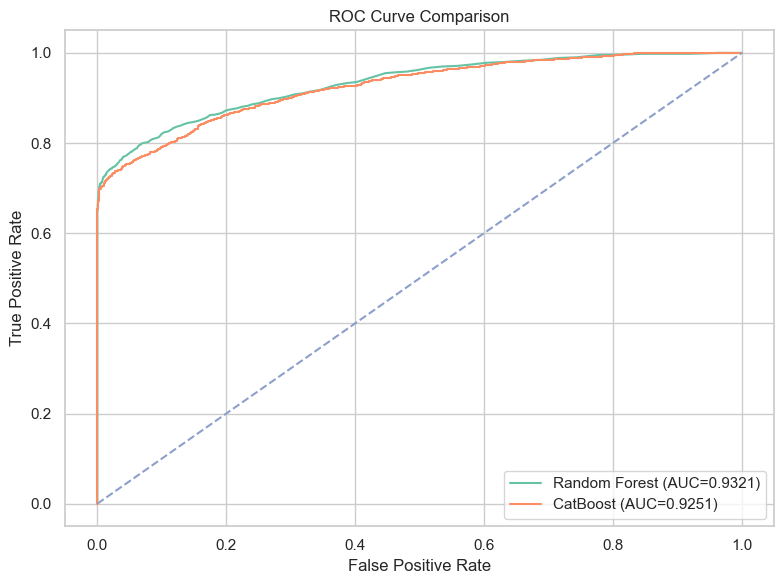

In [160]:
from sklearn.metrics import roc_curve, roc_auc_score

rf_proba = rf.predict_proba(X_test)[:, 1]
cb_proba = cb.predict_proba(X_test)[:, 1]
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_proba)
cb_fpr, cb_tpr, _ = roc_curve(y_test, cb_proba)
rf_auc = roc_auc_score(y_test, rf_proba)
cb_auc = roc_auc_score(y_test, cb_proba)

plt.figure(figsize=(8, 6))
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC={rf_auc:.4f})")
plt.plot(cb_fpr, cb_tpr, label=f"CatBoost (AUC={cb_auc:.4f})")
plt.plot([0, 1], [0, 1],"--")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

---

## 🏁 Kết Luận & Đề Xuất

### 📊 Tóm tắt hiệu suất mô hình
- So sánh **Random Forest** vs **CatBoost** trên các chỉ số: ROC-AUC, Accuracy, Precision, Recall, F1-Score.
- Mô hình tốt nhất sẽ được chọn dựa trên **ROC-AUC** — chỉ số phù hợp nhất cho bài toán phân loại mất cân bằng.

### 💡 Đề xuất kinh doanh
- 🎯 Ưu tiên kiểm soát nhóm khách hàng có **tỷ lệ vay/thu nhập cao** và **loan grade thấp**.
- 🔍 Tăng cường thẩm định với nhóm có **tiền sử vỡ nợ** hoặc vay để **gộp nợ**.
- 📈 Cân nhắc sử dụng **ngưỡng phân loại tùy chỉnh** (threshold tuning) để cân bằng giữa Precision và Recall theo yêu cầu nghiệp vụ.

---


In [ ]:
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("=" * 70)
print("FINAL MODEL PERFORMANCE REPORT")
print("=" * 70)

rf_probs = rf.predict_proba(X_test)[:, 1]
cb_probs = cb.predict_proba(X_test)[:, 1]

rf_preds = rf.predict(X_test)
cb_preds = cb.predict(X_test)

rf_auc = roc_auc_score(y_test, rf_probs)
cb_auc = roc_auc_score(y_test, cb_probs)

for name, probs, preds in [
    ("Random Forest", rf_probs, rf_preds),
    ("CatBoost", cb_probs, cb_preds)
]:
    print(f"\n{name}")
    print("-" * 70)
    print(f"ROC-AUC   : {roc_auc_score(y_test, probs):.4f}")
    print(f"Accuracy  : {accuracy_score(y_test, preds):.4f}")
    print(f"Precision : {precision_score(y_test, preds):.4f}")
    print(f"Recall    : {recall_score(y_test, preds):.4f}")
    print(f"F1-Score  : {f1_score(y_test, preds):.4f}")

print("\n" + "=" * 70)
print("TOP RISK FACTORS (CATBOOST)")
print("=" * 70)

for i, feature in enumerate(cb_importance.head(5)["feature"].tolist(), 1):
    print(f"{i}. {feature}")

print("\n" + "=" * 70)
print("BUSINESS INSIGHTS")
print("=" * 70)
print("• Higher loan-to-income ratio increases default risk.")
print("• Lower income borrowers are more likely to default.")
print("• Poor loan grades are strongly associated with default.")
print("• Home ownership status contributes to risk prediction.")
print("• Loan purpose contains meaningful risk information.")

selected_model = "CatBoost" if cb_auc >= rf_auc else "Random Forest"

print("\n" + "=" * 70)
print(f"SELECTED MODEL : {selected_model}")
print(f"RF ROC-AUC     : {rf_auc:.4f}")
print(f"CB ROC-AUC     : {cb_auc:.4f}")
print("=" * 70)


FINAL MODEL PERFORMANCE REPORT

Random Forest
----------------------------------------------------------------------
ROC-AUC   : 0.9321
Accuracy  : 0.9331
Precision : 0.9786
Recall    : 0.7089
F1-Score  : 0.8222

CatBoost
----------------------------------------------------------------------
ROC-AUC   : 0.9251
Accuracy  : 0.9309
Precision : 0.9860
Recall    : 0.6934
F1-Score  : 0.8142

TOP RISK FACTORS (CATBOOST)
1. loan_percent_income
2. person_home_ownership
3. loan_grade
4. person_income
5. loan_intent

BUSINESS INSIGHTS
• Higher loan-to-income ratio increases default risk.
• Lower income borrowers are more likely to default.
• Poor loan grades are strongly associated with default.
• Home ownership status contributes to risk prediction.
• Loan purpose contains meaningful risk information.

SELECTED MODEL : Random Forest
RF ROC-AUC     : 0.9321
CB ROC-AUC     : 0.9251
